# CPU+GPU Test of `calcSpatialFreqsHilbert2D`

This notebook replicates in Python/NumPy the MATLAB test script `testCalcSpatialFreqsHilbert2D.m` for the 2D Hilbert-based local spatial-frequency estimator `calcSpatialFreqsHilbert2D`. The core functions are imported from `FPA_Numpy.py` and `FPA_TensorFlow.py` .
Here we check NumPy-CPU and TensorFlow-GPU implementations

In [1]:
# ---
# ✅ Colab bootstrap for LensPMD
# How to open in Colab:
# 1) Clone the LensPMD repo into Google Drive.
# 2) In Drive (web), right-click the notebook → “Open with” → “Google Colab”.
# 3) Run this cell to mount Drive, set the working directory, and verify required paths.
# ---

import os
from pathlib import Path

# === Detect Colab =============================================================
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab? {IN_COLAB}")

# === Setup when in Colab ======================================================
if IN_COLAB:
    from google.colab import drive  # type: ignore
    DRIVE_MOUNT_POINT = "/content/drive"
    PROJECT_REL_PATH = "MyDrive/Colab Notebooks/72_OM4M008_LENSPMD25_CPU_GPU_FPA/Python_src"
    REQUIRED_PATH = "/content/drive/MyDrive/Colab Notebooks/72_OM4M008_LENSPMD25_CPU_GPU_FPA/local_data"

    # Mount Google Drive
    drive.mount(DRIVE_MOUNT_POINT, force_remount=True)

    # Set working directory
    project_path = Path(DRIVE_MOUNT_POINT) / PROJECT_REL_PATH
    if not project_path.exists():
        raise FileNotFoundError(f"❌ Project directory not found: {project_path}")

    os.chdir(project_path)
    print("✅ Working Directory:", Path.cwd())

    # Verify required local_data folder exists
    local_data_path = Path(REQUIRED_PATH)
    if not local_data_path.exists():
        raise FileNotFoundError(
            f"❌ Required directory not found: {local_data_path}\n"
            "Please ensure 'local_data' exists in the LensPMD folder in your Drive."
        )

    print("✅ Required folder found:", local_data_path)
    print("📂 Files in Working Directory:", os.listdir())

else:
    print("Not running in Colab — skipping Drive mount and WD setup.")
    print("Current Working Directory:", Path.cwd())


Running in Colab? False
Not running in Colab — skipping Drive mount and WD setup.
Current Working Directory: c:\user\AQ_SCC\72_OM4M008_LENSPMD25_CPU_GPU_FPA\Python_src


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from FPA_Numpy import calcSpatialFreqsHilbert2D_NumPy, calcSpatialFreqsFilterbank_ParVer_NumPy
from FPA_TensorFlow import calcSpatialFreqsHilbert2D_TF, calcSpatialFreqsFilterbank_ParVer_TF
from FPA_Utils import time_function, peaks_2d

from functools import partial



c:\ProgramData\anaconda3\envs\LENSPMD25-base310\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [3]:
# Synthetic interferogram (Caso 1: HIFREQ)
NR, NC = 558, 553
y, x = np.meshgrid(
    np.arange(NR, dtype=np.float32),
    np.arange(NC, dtype=np.float32),
    indexing="ij",
)
x = x - 0.5 * NC
y = y - 0.5 * NR

# ROI mask
M = np.ones((NR, NC), dtype=bool)

# Spatial carrier
w0 = np.array([np.pi/4, np.pi/4], dtype=np.float32)  # rad/px
fringe_carrier_or = np.arctan2(w0[1], w0[0])

# Smooth phase term via peaks (already sized NR x NC)
phi_0 = 3.0 * peaks_2d(NR, NC)
phi = phi_0 + w0[0] * x + w0[1] * y

# Ground-truth spatial freqs
phi_y, phi_x = np.gradient(phi.astype(np.float32))  # np.gradient -> (d/dy, d/dx)
w_phi = np.abs(phi_x + 1j * phi_y)
w_phi = w_phi * M  # apply mask
theta_or = np.arctan2(-phi_y, phi_x)

# DC and modulation in gray values
b = np.float32(100.0)
m = np.float32(64.0)
nL_mod = np.float32(0.0)
nL = 100.0 * nL_mod / m  # not used explicitly

# Interferogram in [0, 255]
g_float = b + m * np.cos(phi) + nL_mod * np.random.randn(NR, NC).astype(np.float32)
g_uint8 = np.clip(np.round(g_float), 0, 255).astype(np.uint8)
g = g_uint8.astype(np.float32)
g = g * M.astype(np.float32)

# Ground-truth phasor (for reference)
z = b * np.exp(1j * phi)
print("Synthetic interferogram generated.")


Synthetic interferogram generated.


[calcSpatialFreqsHilbert2D_NumPy] Warm-up time: 51.04 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 1/10: 52.93 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 2/10: 51.62 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 3/10: 50.82 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 4/10: 54.72 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 5/10: 51.35 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 6/10: 50.90 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 7/10: 51.69 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 8/10: 54.48 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 9/10: 59.00 ms
[calcSpatialFreqsHilbert2D_NumPy] Run 10/10: 50.70 ms
calcSpatialFreqsHilbert2D_NumPy: 10 runs -> mean = 52.82 ms, std = 2.48 ms


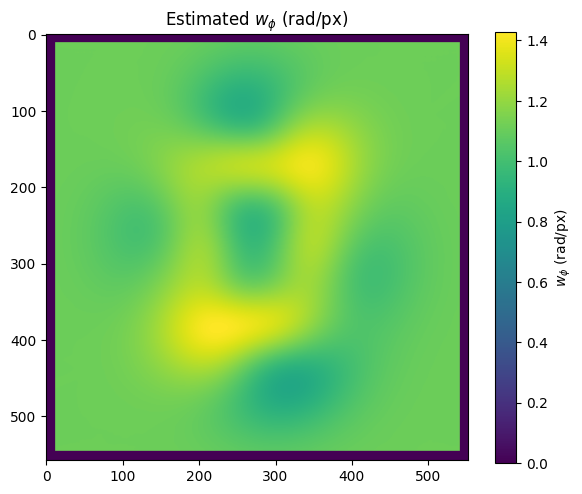

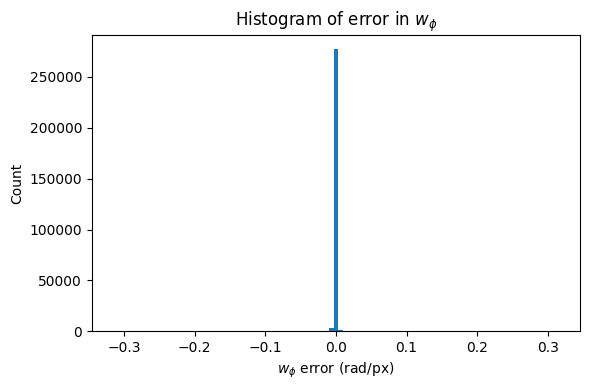

RMSE(w_phi) = 0.3214 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px


In [4]:
# Time Numpy Filterbank-based method (outputs kept if needed)
# use partial to keep funcion metadata
f_calcSpatialFreqsHilbert2D_NumPy = partial(calcSpatialFreqsHilbert2D_NumPy, g, M, filter_orientation=fringe_carrier_or)

# Time NumPy Hilbert-based method and keep outputs for plotting
res_calcSpatialFreqsHilbert2D_NumPy = time_function(f_calcSpatialFreqsHilbert2D_NumPy.func.__name__, f_calcSpatialFreqsHilbert2D_NumPy, n_runs=10, verbose=True)


# calculate spatial freqs
(pred_w_phi, pred_theta_or, pred_phi_x, pred_phi_y, M_proc)=f_calcSpatialFreqsHilbert2D_NumPy()

# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


[calcSpatialFreqsHilbert2D_TF] Warm-up time: 115.07 ms
[calcSpatialFreqsHilbert2D_TF] Run 1/10: 46.23 ms
[calcSpatialFreqsHilbert2D_TF] Run 2/10: 45.36 ms
[calcSpatialFreqsHilbert2D_TF] Run 3/10: 46.22 ms
[calcSpatialFreqsHilbert2D_TF] Run 4/10: 44.88 ms
[calcSpatialFreqsHilbert2D_TF] Run 5/10: 45.89 ms
[calcSpatialFreqsHilbert2D_TF] Run 6/10: 45.86 ms
[calcSpatialFreqsHilbert2D_TF] Run 7/10: 46.22 ms
[calcSpatialFreqsHilbert2D_TF] Run 8/10: 44.46 ms
[calcSpatialFreqsHilbert2D_TF] Run 9/10: 45.10 ms
[calcSpatialFreqsHilbert2D_TF] Run 10/10: 45.31 ms
calcSpatialFreqsHilbert2D_TF: 10 runs -> mean = 45.55 ms, std = 0.59 ms


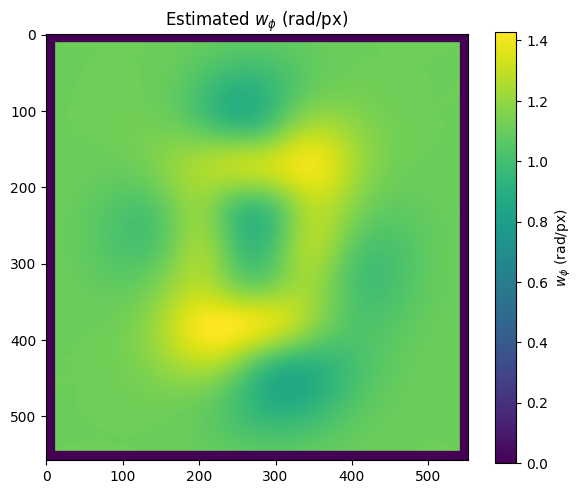

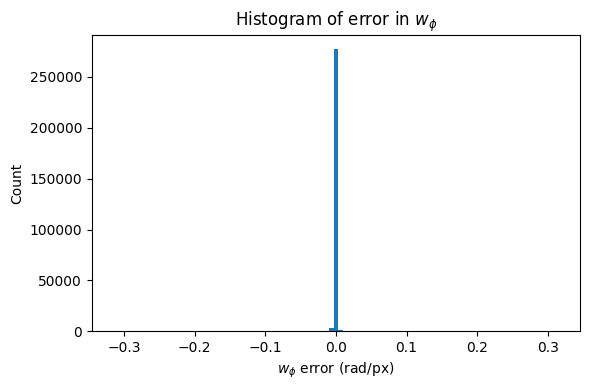

RMSE(w_phi) = 0.3214 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px


In [5]:
# Time tensorFlow Hilbert2D method (outputs kept if needed)
# use partial to keep funcion metadata
f_calcSpatialFreqsHilbert2D_TF = partial(calcSpatialFreqsHilbert2D_TF, g, M, filter_orientation=fringe_carrier_or)

# Time TensorFlow Hilbert-based method and keep outputs for plotting
res_calcSpatialFreqsHilbert2D_TF = time_function(f_calcSpatialFreqsHilbert2D_TF.func.__name__, f_calcSpatialFreqsHilbert2D_TF, n_runs=10, verbose=True)

# calculate spatial freqs
(pred_w_phi, pred_theta_or, pred_phi_x, pred_phi_y, M_proc)=f_calcSpatialFreqsHilbert2D_TF()

# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


[calcSpatialFreqsFilterbank_ParVer_NumPy] Warm-up time: 4575.45 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 1/10: 4650.19 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 2/10: 4692.48 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 3/10: 4566.82 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 4/10: 4668.14 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 5/10: 4691.64 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 6/10: 4686.23 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 7/10: 4694.37 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 8/10: 4612.09 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 9/10: 4587.58 ms
[calcSpatialFreqsFilterbank_ParVer_NumPy] Run 10/10: 4551.57 ms
calcSpatialFreqsFilterbank_ParVer_NumPy: 10 runs -> mean = 4640.11 ms, std = 53.02 ms


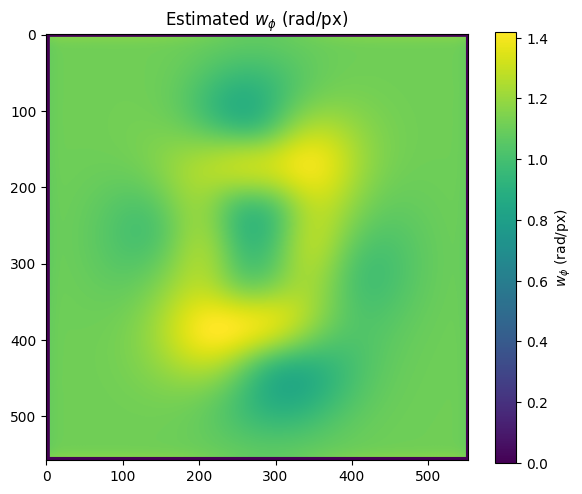

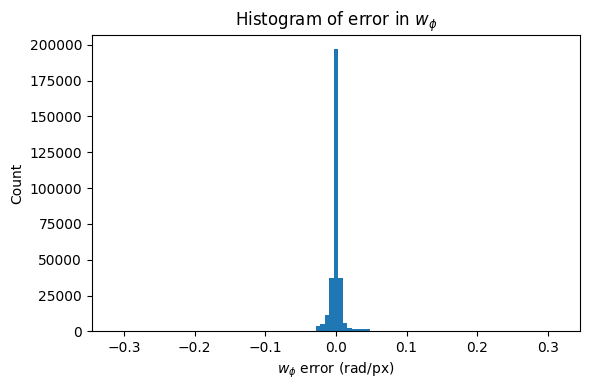

RMSE(w_phi) = 0.0082 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px


In [6]:
# Time numpy paralell filter bank method (outputs kept if needed)
# use partial to keep funcion metadata
f_calcSpatialFreqsFilterbank_ParVer_NumPy = partial(calcSpatialFreqsFilterbank_ParVer_NumPy, g, M)

# Time  numpy paralell filter bank method and keep outputs for plotting
res_calcSpatialFreqsFilterbank_ParVer_NumPy = time_function(f_calcSpatialFreqsFilterbank_ParVer_NumPy.func.__name__, f_calcSpatialFreqsFilterbank_ParVer_NumPy, n_runs=10, verbose=True)

# calculate spatial freqs
(pred_w_phi, pred_theta_or, pred_phi_x, pred_phi_y, M_proc)=f_calcSpatialFreqsFilterbank_ParVer_NumPy()

# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


[calcSpatialFreqsFilterbank_ParVer_TF] Warm-up time: 887.31 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 1/10: 634.67 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 2/10: 614.30 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 3/10: 611.52 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 4/10: 612.37 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 5/10: 602.21 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 6/10: 598.64 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 7/10: 601.26 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 8/10: 610.70 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 9/10: 613.50 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 10/10: 604.13 ms
calcSpatialFreqsFilterbank_ParVer_TF: 10 runs -> mean = 610.33 ms, std = 9.73 ms


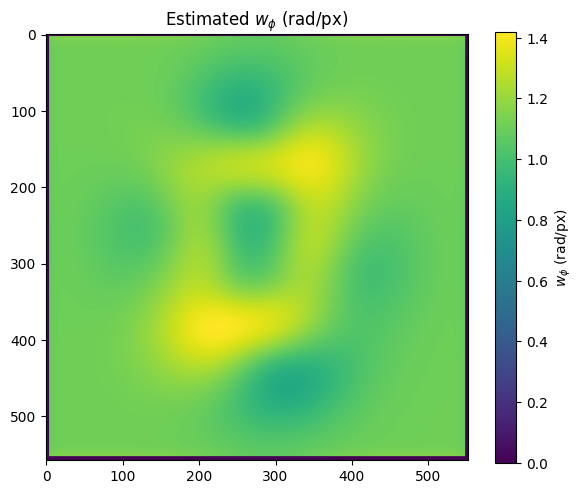

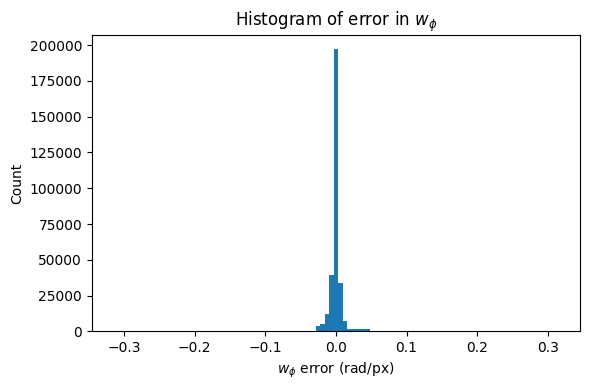

RMSE(w_phi) = 0.0082 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px
 
*** Profile stats marshalled to file 'out.prof'.


         949051 function calls (920601 primitive calls) in 8.063 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     3792    7.054    0.002    7.054    0.002 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_FastPathExecute}
      288    0.220    0.001    0.220    0.001 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_Execute}
     1968    0.033    0.000    0.041    0.000 constant_op.py:75(convert_to_eager_tensor)
        3    0.033    0.011    0.033    0.011 {method 'encode' of 'ImagingEncoder' objects}
5376/2700    0.024    0.000    5.620    0.002 dispatch.py:1246(op_dispatch_handler)
     8701    0.022    0.000    0.022    0.000 {method 'copy' of 'numpy.ndarray' objects}
35843/35789    0.020    0.000    0.027    0.000 {built-in method builtins.getattr}
        4    0.015    0.004    0.015    0.004 {built-in method matplotlib._image.resample}
      198    0.015    0.000    0.015    0.000 {method 'astype' of 'num

In [7]:
%%prun -D out.prof

# Time tensor flow paralell filter bank method (outputs kept if needed)
# use partial to keep funcion metadata
f_calcSpatialFreqsFilterbank_ParVer_TF = partial(calcSpatialFreqsFilterbank_ParVer_TF, g, M)

# Time tensor flow paralell filter bank method and keep outputs for plotting
res_calcSpatialFreqsFilterbank_ParVer_TF = time_function(f_calcSpatialFreqsFilterbank_ParVer_TF.func.__name__, f_calcSpatialFreqsFilterbank_ParVer_TF, n_runs=10, verbose=True)

# calculate spatial freqs
(pred_w_phi, pred_theta_or, pred_phi_x, pred_phi_y, M_proc)=f_calcSpatialFreqsFilterbank_ParVer_TF()


# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


In [16]:
import snakeviz
print(snakeviz.__file__)
!snakeviz out.prof

c:\ProgramData\anaconda3\envs\LENSPMD25-base310\lib\site-packages\snakeviz\__init__.py
^C
